To run the code, set to GPU and upload the news and elon musk's post dataset as instructed, and run all code blocks.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from google.colab import files
import io

def upload_datasets():
    try:
        print("Please upload the Tesla news CSV file:")
        uploaded_news = files.upload()
        news_filename = list(uploaded_news.keys())[0]
        tesla_news_df = pd.read_csv(io.BytesIO(uploaded_news[news_filename]))

        print("\nPlease upload 'elonMuskPosts.csv' file:")
        uploaded_tweets = files.upload()
        tweets_filename = list(uploaded_tweets.keys())[0]
        musk_tweets_df = pd.read_csv(io.BytesIO(uploaded_tweets[tweets_filename]))

        return tesla_news_df, musk_tweets_df

    except Exception as e:
        print(f"Error: {e}")
        return None, None

# Upload and load the files
tesla_news_df, musk_tweets_df = upload_datasets()

if tesla_news_df is not None and musk_tweets_df is not None:
    # Display basic information about the datasets
    print("\nTesla News Dataset Info:")
    print("-----------------------")
    print(tesla_news_df.info())
    print("\nFirst few rows of Tesla news data:")
    print(tesla_news_df.head())

    print("\nElon Musk Twitter Dataset Info:")
    print("------------------------------")
    print(musk_tweets_df.info())
    print("\nFirst few rows of Twitter data:")
    print(musk_tweets_df.head())

    # Print the shapes of both datasets
    print(f"\nTesla news dataset shape: {tesla_news_df.shape}")
    print(f"Elon Musk tweets dataset shape: {musk_tweets_df.shape}")

    # Check for missing values
    print("\nMissing values in Tesla News Dataset:")
    print(tesla_news_df.isnull().sum())
    print("\nMissing values in Twitter Dataset:")
    print(musk_tweets_df.isnull().sum())

Please upload the Tesla news CSV file:


Saving news.csv to news.csv

Please upload 'elonMuskPosts.csv' file:


Saving elonMuskPosts.csv to elonMuskPosts.csv

Tesla News Dataset Info:
-----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  764 non-null    int64 
 1   date        764 non-null    object
 2   source      764 non-null    object
 3   title       764 non-null    object
 4   link        764 non-null    object
 5   content     764 non-null    object
dtypes: int64(1), object(5)
memory usage: 35.9+ KB
None

First few rows of Tesla news data:
   Unnamed: 0         date                                     source  \
0           0  28 Apr 2022  New York Times, Late Edition (East Coast)   
1           1  18 May 2022               Wall Street Journal (Online)   
2           2  14 Nov 2022               Wall Street Journal (Online)   
3           3  15 Nov 2022               Wall Street Journal (Online)   
4           4  21 May 2

Using device: cuda


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Device set to use cuda:0
/usr/local/lib/python3.11/dist-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


Datasets loaded successfully
Tesla news dataset shape: (764, 6)
Elon Musk tweets dataset shape: (5390, 26)
Processing news dataset...


100%|██████████| 24/24 [00:07<00:00,  3.39it/s]


Processing tweets dataset...


100%|██████████| 169/169 [00:49<00:00,  3.43it/s]



Date ranges in datasets:
News dataset: from 2022-01-03 00:00:00 to 2022-12-31 00:00:00
Tweets dataset: from 2022-01-01 00:00:00 to 2022-12-31 00:00:00
Calculating weighted sentiments...

Monthly data before processing:
      month  sales
0   2022-01  37594
1   2022-02  36202
2   2022-03  89575
3   2022-04  40568
4   2022-05  39066
5   2022-06  39066
6   2022-07  37518
7   2022-08  38962
8   2022-09  37518
9   2022-10  46667
10  2022-11  44800
11  2022-12  48533

Training data (First 6 months):
     month  sales
0  2022-01  37594
1  2022-02  36202
2  2022-03  89575
3  2022-04  40568
4  2022-05  39066
5  2022-06  39066

Test data (Last 6 months):
      month  sales
6   2022-07  37518
7   2022-08  38962
8   2022-09  37518
9   2022-10  46667
10  2022-11  44800
11  2022-12  48533
Epoch [100/1000], Loss: 17892950.0000
Epoch [200/1000], Loss: 755674.1250
Epoch [300/1000], Loss: 26330.2695
Epoch [400/1000], Loss: 2198.1863
Epoch [500/1000], Loss: 90.5988
Epoch [600/1000], Loss: 14.1212
Epoch 

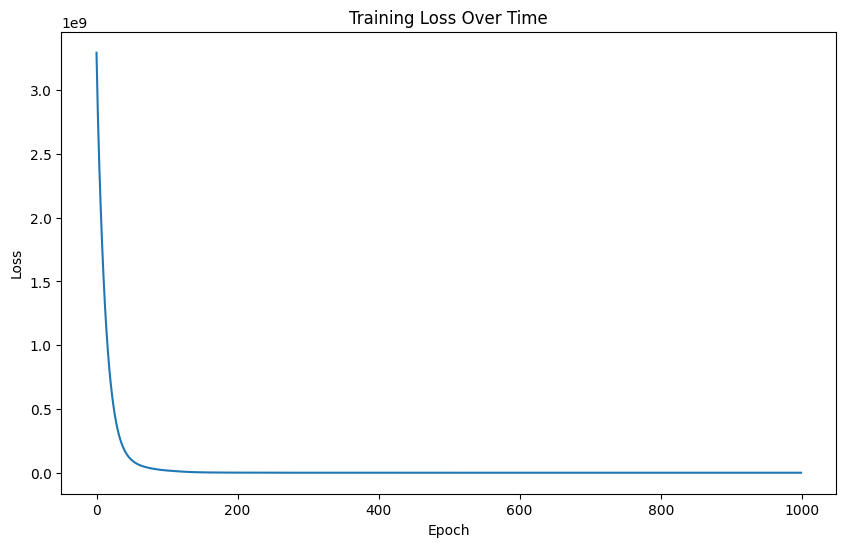


Test Results:
RMSE: 37474.27
R2 Score: -68.61
MAPE: 55.77%

Predictions vs Actuals:
      Month  Actual Sales  Predicted Sales
6   2022-07         37518     37050.785156
7   2022-08         38962     50238.742188
8   2022-09         37518    126783.531250
9   2022-10         46667     36457.554688
10  2022-11         44800     36202.125000
11  2022-12         48533     36202.039062


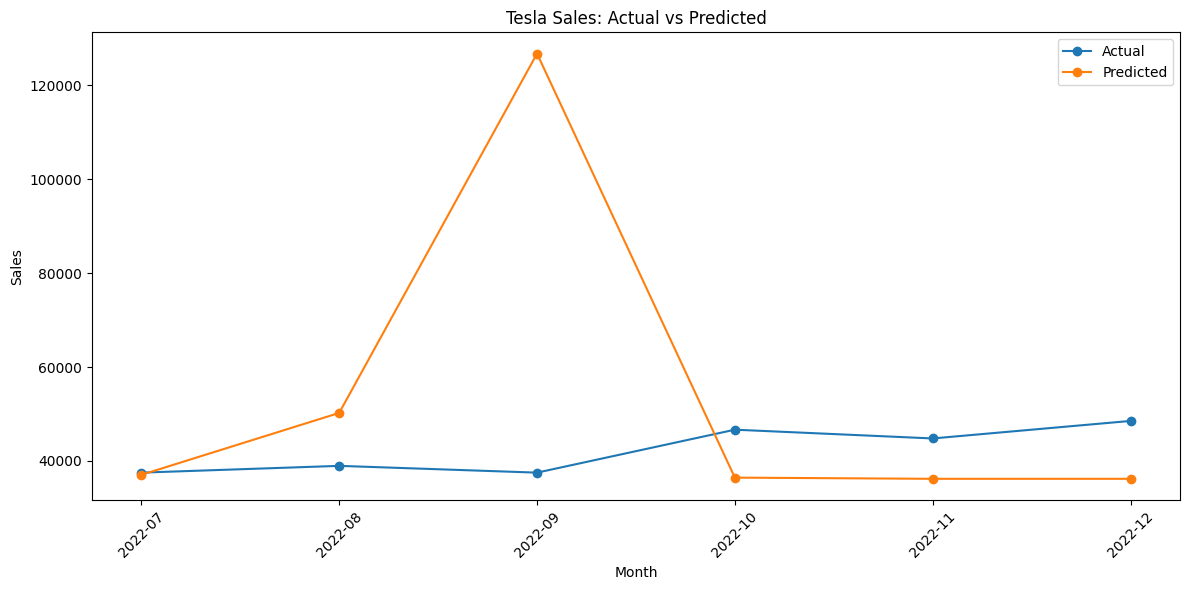

In [15]:
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.preprocessing import MinMaxScaler
import torch
from datetime import datetime
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim.lr_scheduler import ReduceLROnPlateau


# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_datasets():
    """Load the Tesla news and Elon Musk tweets datasets"""
    try:
        # Load Tesla news dataset
        tesla_news_df = pd.read_csv('news.csv')

        # Load Elon Musk tweets dataset
        musk_tweets_df = pd.read_csv('elonMuskPosts.csv')

        print("Datasets loaded successfully")
        print(f"Tesla news dataset shape: {tesla_news_df.shape}")
        print(f"Elon Musk tweets dataset shape: {musk_tweets_df.shape}")

        return tesla_news_df, musk_tweets_df
    except Exception as e:
        print(f"Error loading datasets: {e}")
        return None, None

# Sales data
# Sales data for January to December 2022
monthly_sales = {
    '2022-01': 37594,
    '2022-02': 36202,
    '2022-03': 89575,
    '2022-04': 40568,
    '2022-05': 39066,
    '2022-06': 39066,
    '2022-07': 37518,
    '2022-08': 38962,
    '2022-09': 37518,
    '2022-10': 46667,
    '2022-11': 44800,
    '2022-12': 48533
}

# Initialize sentiment analyzer
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="finiteautomata/bertweet-base-sentiment-analysis",
    device=0 if torch.cuda.is_available() else -1,
    return_all_scores=True
)

def batch_sentiment_analysis(texts, batch_size=32):
    """Process sentiments in batches"""
    results = []
    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]
        batch = [str(text)[:128] for text in batch]  # Convert to string and truncate
        try:
            batch_results = sentiment_analyzer(batch)
            for res in batch_results:
                sentiment_dict = {score['label']: score['score'] for score in res}
                composite_score = sentiment_dict['POS'] - sentiment_dict['NEG']
                results.append({
                    'sentiment_score': composite_score,
                    'positive_score': sentiment_dict['POS'],
                    'neutral_score': sentiment_dict['NEU'],
                    'negative_score': sentiment_dict['NEG']
                })
        except Exception as e:
            print(f"Error in batch processing: {e}")
            for _ in range(len(batch)):
                results.append({
                    'sentiment_score': 0,
                    'positive_score': 0,
                    'neutral_score': 0,
                    'negative_score': 0
                })
    return pd.DataFrame(results)

def parse_date(date_str):
    try:
        # Format for news dataset: "28 Apr 2022"
        formats = [
            '%d %b %Y',      # For "28 Apr 2022"
            '%d/%m/%Y',      # For "1/1/2022"
            '%Y-%m-%d',      # For ISO format
            '%d %B %Y',      # For full month name
        ]

        for fmt in formats:
            try:
                return pd.to_datetime(date_str, format=fmt)
            except:
                continue

        # If none of the specific formats work, try pandas default parser
        return pd.to_datetime(date_str)
    except Exception as e:
        print(f"Failed to parse date: {date_str}, Error: {e}")
        return None

def process_datasets(tesla_news_df, musk_tweets_df):
    """Process both datasets"""
    print("Processing news dataset...")

    # Process news dataset
    tesla_news_df['parsed_date'] = tesla_news_df['date'].apply(parse_date)
    tesla_news_df['month'] = tesla_news_df['parsed_date'].dt.strftime('%Y-%m')
    news_sentiments = batch_sentiment_analysis(tesla_news_df['content'].tolist())
    tesla_news_df = pd.concat([tesla_news_df, news_sentiments], axis=1)

    print("Processing tweets dataset...")
    # Process tweets dataset - using the date column directly
    musk_tweets_df['parsed_date'] = pd.to_datetime(musk_tweets_df['date'])
    musk_tweets_df['month'] = musk_tweets_df['parsed_date'].dt.strftime('%Y-%m')
    tweet_sentiments = batch_sentiment_analysis(musk_tweets_df['fullText'].tolist())
    musk_tweets_df = pd.concat([musk_tweets_df, tweet_sentiments], axis=1)

    # Print date ranges for debugging
    print("\nDate ranges in datasets:")
    print("News dataset:",
          f"from {tesla_news_df['parsed_date'].min()} to {tesla_news_df['parsed_date'].max()}")
    print("Tweets dataset:",
          f"from {musk_tweets_df['parsed_date'].min()} to {musk_tweets_df['parsed_date'].max()}")

    return tesla_news_df, musk_tweets_df

def calculate_weighted_sentiments(df):
    """Calculate weighted sentiments based on engagement"""
    engagement_score = np.log1p(
        df['likeCount'].fillna(0) +
        df['retweetCount'].fillna(0) * 2 +
        df['replyCount'].fillna(0) +
        df['quoteCount'].fillna(0)
    )

    return pd.DataFrame({
        'weighted_sentiment': df['sentiment_score'] * engagement_score,
        'weighted_positive': df['positive_score'] * engagement_score,
        'weighted_neutral': df['neutral_score'] * engagement_score,
        'weighted_negative': df['negative_score'] * engagement_score
    })

def aggregate_monthly_data(tesla_news_df, musk_tweets_df):
    """Aggregate data by month"""
    monthly_news = tesla_news_df.groupby('month').agg({
        'sentiment_score': ['mean', 'std'],
        'positive_score': ['mean', 'sum'],
        'negative_score': ['mean', 'sum'],
        'neutral_score': ['mean', 'sum'],
        'content': 'count'
    }).reset_index()

    monthly_tweets = musk_tweets_df.groupby('month').agg({
        'sentiment_score': ['mean', 'std'],
        'weighted_sentiment': 'sum',
        'weighted_positive': 'sum',
        'weighted_neutral': 'sum',
        'weighted_negative': 'sum',
        'retweetCount': 'mean',
        'likeCount': 'mean',
        'replyCount': 'mean',
        'fullText': 'count'
    }).reset_index()

    # Flatten column names
    monthly_news.columns = ['month'] + [f'news_{a}_{b}' if b else f'news_{a}'
                                      for a, b in monthly_news.columns[1:]]
    monthly_tweets.columns = ['month'] + [f'tweets_{a}_{b}' if b else f'tweets_{a}'
                                        for a, b in monthly_tweets.columns[1:]]

    return monthly_news, monthly_tweets

class EnhancedSalesPredictor(nn.Module):
    def __init__(self, input_size):
        super(EnhancedSalesPredictor, self).__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

        # Initialize weights
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.xavier_uniform_(self.fc3.weight)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softplus(self.fc3(x))  # Ensure positive output
        return x * 100000  # Scale up the output


def train_model(train_data, test_data, feature_columns, epochs=1000):
    """Train the neural network model"""
    X_train = torch.FloatTensor(train_data[feature_columns].values).to(device)
    y_train = torch.FloatTensor(train_data['sales'].values).to(device)
    X_test = torch.FloatTensor(test_data[feature_columns].values).to(device)
    y_test = torch.FloatTensor(test_data['sales'].values).to(device)

    # Scale targets
    y_scaler = MinMaxScaler()
    y_train_scaled = torch.FloatTensor(y_scaler.fit_transform(y_train.cpu().numpy().reshape(-1, 1))).to(device)
    y_test_scaled = torch.FloatTensor(y_scaler.transform(y_test.cpu().numpy().reshape(-1, 1))).to(device)

    model = EnhancedSalesPredictor(len(feature_columns)).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=20, factor=0.5, verbose=True)

    best_loss = float('inf')
    best_model_state = None
    patience = 50
    patience_counter = 0

    train_losses = []

    try:
        for epoch in range(epochs):
            model.train()
            optimizer.zero_grad()
            outputs = model(X_train)
            loss = criterion(outputs, y_train_scaled)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            scheduler.step(loss.item())

            if loss.item() < best_loss:
                best_loss = loss.item()
                patience_counter = 0
                best_model_state = model.state_dict().copy()
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                if best_model_state is not None:
                    model.load_state_dict(best_model_state)
                break

            if (epoch + 1) % 100 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

    except Exception as e:
        print(f"Error during training: {e}")
        if best_model_state is not None:
            model.load_state_dict(best_model_state)

    # Plot training loss
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses)
    plt.title('Training Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    return model, X_test, y_test_scaled, y_scaler



def evaluate_model(model, X_test, y_test, test_data, y_scaler):
    """Evaluate the model and display results"""
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test).cpu().numpy()

    # Inverse transform predictions and actual values
    test_predictions = y_scaler.inverse_transform(test_predictions)
    if hasattr(y_test, 'cpu'):
        y_test = y_test.cpu().numpy()
    y_test = y_scaler.inverse_transform(y_test.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
    r2 = r2_score(y_test, test_predictions)
    mape = mean_absolute_percentage_error(y_test, test_predictions)

    print("\nTest Results:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.2f}")
    print(f"MAPE: {mape:.2%}")

    results_df = pd.DataFrame({
        'Month': test_data['month'],
        'Actual Sales': test_data['sales'],
        'Predicted Sales': test_predictions.flatten()
    })

    print("\nPredictions vs Actuals:")
    print(results_df.to_string())

    # Plot actual vs predicted
    plt.figure(figsize=(12, 6))
    plt.plot(results_df['Month'], results_df['Actual Sales'], label='Actual', marker='o')
    plt.plot(results_df['Month'], results_df['Predicted Sales'], label='Predicted', marker='o')
    plt.title('Tesla Sales: Actual vs Predicted')
    plt.xlabel('Month')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results_df

def main():
    # Load datasets
    tesla_news_df, musk_tweets_df = load_datasets()

    if tesla_news_df is None or musk_tweets_df is None:
        print("Failed to load datasets. Exiting...")
        return None, None

    # Process datasets
    tesla_news_df, musk_tweets_df = process_datasets(tesla_news_df, musk_tweets_df)

    # Calculate weighted sentiments for tweets
    print("Calculating weighted sentiments...")
    weighted_sentiments = calculate_weighted_sentiments(musk_tweets_df)
    musk_tweets_df = pd.concat([musk_tweets_df, weighted_sentiments], axis=1)

    # Aggregate monthly data
    monthly_news, monthly_tweets = aggregate_monthly_data(tesla_news_df, musk_tweets_df)

    # Merge all features
    monthly_data = pd.merge(monthly_news, monthly_tweets, on='month', how='outer')

    # Convert sales dictionary to DataFrame for better merging
    sales_df = pd.DataFrame(list(monthly_sales.items()), columns=['month', 'sales'])

    # Merge with sales data
    monthly_data = pd.merge(monthly_data, sales_df, on='month', how='inner')

    # Sort by month to ensure chronological order
    monthly_data = monthly_data.sort_values('month')

    print("\nMonthly data before processing:")
    print(monthly_data[['month', 'sales']].to_string())

    if len(monthly_data) < 12:
        print("\nError: Need at least 12 months of data")
        print(f"Currently have {len(monthly_data)} months")
        return None, None

    # Prepare for modeling
    feature_columns = [col for col in monthly_data.columns
                      if col not in ['month', 'sales']]

    # Scale features
    scaler = MinMaxScaler()
    monthly_data[feature_columns] = scaler.fit_transform(monthly_data[feature_columns])

    # Use first 6 months for training, last 6 months for testing
    train_data = monthly_data[:6]
    test_data = monthly_data[6:]

    print("\nTraining data (First 6 months):")
    print(train_data[['month', 'sales']].to_string())
    print("\nTest data (Last 6 months):")
    print(test_data[['month', 'sales']].to_string())

    # Train model
    model, X_test, y_test, y_scaler = train_model(train_data, test_data, feature_columns)

    # Evaluate model
    results = evaluate_model(model, X_test, y_test, test_data, y_scaler)

    return results, model


if __name__ == "__main__":
    results, model = main()

Improving accuracy

Datasets loaded successfully
Tesla news dataset shape: (764, 6)
Elon Musk tweets dataset shape: (5390, 26)
Processing news dataset...


100%|██████████| 24/24 [00:06<00:00,  3.46it/s]


Processing tweets dataset...


100%|██████████| 169/169 [00:48<00:00,  3.45it/s]
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([6])) that is different to the input size (torch.Size([6, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



Date ranges in datasets:
News dataset: from 2022-01-03 00:00:00 to 2022-12-31 00:00:00
Tweets dataset: from 2022-01-01 00:00:00 to 2022-12-31 00:00:00

Monthly data shape: (12, 13)
Epoch [100/1000], Train Loss: 368685248.0000, Val Loss: 65915676.0000
Epoch [200/1000], Train Loss: 364902016.0000, Val Loss: 57126356.0000
Epoch [300/1000], Train Loss: 364332704.0000, Val Loss: 50569424.0000
Epoch [400/1000], Train Loss: 364206848.0000, Val Loss: 47516220.0000
Epoch [500/1000], Train Loss: 364170912.0000, Val Loss: 46199104.0000
Epoch [600/1000], Train Loss: 364162688.0000, Val Loss: 45577664.0000
Epoch [700/1000], Train Loss: 364161312.0000, Val Loss: 45313976.0000
Epoch [800/1000], Train Loss: 364161152.0000, Val Loss: 45218076.0000
Epoch [900/1000], Train Loss: 364161152.0000, Val Loss: 45187576.0000
Epoch [1000/1000], Train Loss: 364161152.0000, Val Loss: 45179300.0000

Test Results:
RMSE: 7639.41
R2 Score: -1.89
MAPE: 16.36%

Predictions vs Actuals:
      Month  Actual Sales  Predict

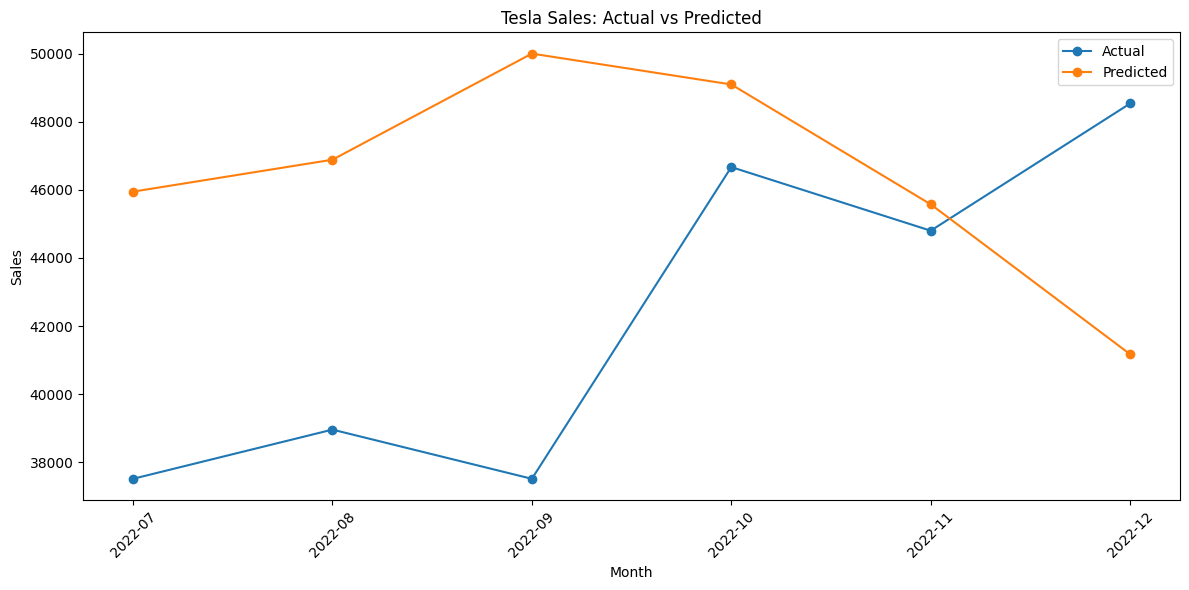

In [17]:
def test_improved_model():
    """Test improved model with simpler architecture and better scaling"""

    # Load and process data using existing functions
    tesla_news_df, musk_tweets_df = load_datasets()
    tesla_news_df, musk_tweets_df = process_datasets(tesla_news_df, musk_tweets_df)

    # Calculate weighted sentiments
    weighted_sentiments = calculate_weighted_sentiments(musk_tweets_df)
    musk_tweets_df = pd.concat([musk_tweets_df, weighted_sentiments], axis=1)

    # Simple but effective monthly aggregation
    def aggregate_enhanced_monthly_data(news_df, tweets_df):
        monthly_news = news_df.groupby('month').agg({
            'sentiment_score': ['mean', 'std'],
            'positive_score': 'mean',
            'negative_score': 'mean',
            'content': 'count'
        }).reset_index()

        monthly_tweets = tweets_df.groupby('month').agg({
            'sentiment_score': ['mean', 'std'],
            'weighted_sentiment': 'sum',
            'retweetCount': 'mean',
            'likeCount': 'mean',
            'fullText': 'count'
        }).reset_index()

        # Flatten column names
        monthly_news.columns = ['month'] + [f'news_{a}_{b}' if b else f'news_{a}'
                                          for a, b in monthly_news.columns[1:]]
        monthly_tweets.columns = ['month'] + [f'tweets_{a}_{b}' if b else f'tweets_{a}'
                                            for a, b in monthly_tweets.columns[1:]]

        return monthly_news, monthly_tweets

    # Simpler model architecture
    class ImprovedSalesPredictor(nn.Module):
        def __init__(self, input_size):
            super(ImprovedSalesPredictor, self).__init__()

            self.fc1 = nn.Linear(input_size, 32)
            self.fc2 = nn.Linear(32, 16)
            self.fc3 = nn.Linear(16, 1)

            # Initialize weights
            nn.init.xavier_uniform_(self.fc1.weight)
            nn.init.xavier_uniform_(self.fc2.weight)
            nn.init.xavier_uniform_(self.fc3.weight)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            # Constrain output to reasonable range (30k-100k)
            x = 30000 + 70000 * torch.sigmoid(self.fc3(x))
            return x

    def train_improved_model(train_data, test_data, feature_columns, epochs=1000):
        X_train = torch.FloatTensor(train_data[feature_columns].values).to(device)
        y_train = torch.FloatTensor(train_data['sales'].values).to(device)
        X_test = torch.FloatTensor(test_data[feature_columns].values).to(device)
        y_test = torch.FloatTensor(test_data['sales'].values).to(device)

        # Simple MinMaxScaler
        scaler = MinMaxScaler()
        X_train_scaled = torch.FloatTensor(scaler.fit_transform(X_train.cpu())).to(device)
        X_test_scaled = torch.FloatTensor(scaler.transform(X_test.cpu())).to(device)

        model = ImprovedSalesPredictor(len(feature_columns)).to(device)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

        best_loss = float('inf')
        best_model_state = None
        patience = 50
        patience_counter = 0

        train_losses = []
        val_losses = []

        try:
            for epoch in range(epochs):
                # Training
                model.train()
                optimizer.zero_grad()
                outputs = model(X_train_scaled)
                loss = criterion(outputs, y_train)
                loss.backward()
                optimizer.step()

                # Validation
                model.eval()
                with torch.no_grad():
                    val_outputs = model(X_test_scaled)
                    val_loss = criterion(val_outputs, y_test)

                train_losses.append(loss.item())
                val_losses.append(val_loss.item())

                if val_loss.item() < best_loss:
                    best_loss = val_loss.item()
                    patience_counter = 0
                    best_model_state = model.state_dict().copy()
                else:
                    patience_counter += 1

                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    model.load_state_dict(best_model_state)
                    break

                if (epoch + 1) % 100 == 0:
                    print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

        except Exception as e:
            print(f"Error during training: {e}")
            if best_model_state is not None:
                model.load_state_dict(best_model_state)

        return model, X_test_scaled, y_test

    # Main execution
    monthly_news, monthly_tweets = aggregate_enhanced_monthly_data(tesla_news_df, musk_tweets_df)
    monthly_data = pd.merge(monthly_news, monthly_tweets, on='month', how='outer')

    sales_df = pd.DataFrame(list(monthly_sales.items()), columns=['month', 'sales'])
    monthly_data = pd.merge(monthly_data, sales_df, on='month', how='inner')
    monthly_data = monthly_data.sort_values('month')

    print("\nMonthly data shape:", monthly_data.shape)

    feature_columns = [col for col in monthly_data.columns
                      if col not in ['month', 'sales']]

    # Split data
    train_data = monthly_data[:6]
    test_data = monthly_data[6:]

    # Train and evaluate
    model, X_test, y_test = train_improved_model(train_data, test_data, feature_columns)

    # Custom evaluation without scaler
    model.eval()
    with torch.no_grad():
        predictions = model(X_test).cpu().numpy()

    results_df = pd.DataFrame({
        'Month': test_data['month'],
        'Actual Sales': test_data['sales'],
        'Predicted Sales': predictions.flatten()
    })

    rmse = np.sqrt(mean_squared_error(test_data['sales'], predictions))
    r2 = r2_score(test_data['sales'], predictions)
    mape = mean_absolute_percentage_error(test_data['sales'], predictions)

    print("\nTest Results:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.2f}")
    print(f"MAPE: {mape:.2%}")

    print("\nPredictions vs Actuals:")
    print(results_df.to_string())

    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(results_df['Month'], results_df['Actual Sales'], label='Actual', marker='o')
    plt.plot(results_df['Month'], results_df['Predicted Sales'], label='Predicted', marker='o')
    plt.title('Tesla Sales: Actual vs Predicted')
    plt.xlabel('Month')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results_df, model

# Run the improved model
if __name__ == "__main__":
    improved_results, improved_model = test_improved_model()